In [1]:
import numpy as np
import matplotlib.pyplot as plt
import skyproj, healpy as hp, h5py, fitsio
from scipy import stats
from scipy.ndimage import gaussian_filter1d

import os
if os.environ['USER'] == 'dhayaa':
    os.environ['PATH'] = f"{os.environ['PATH']}:/software/texlive-2023/bin/x86_64-linux"

plt.rcParams["axes.linewidth"]  = 1.0
plt.rcParams["xtick.major.size"]  = 10
plt.rcParams["xtick.minor.size"]  = 5
plt.rcParams["ytick.major.size"]  = 10
plt.rcParams["ytick.minor.size"]  = 5
plt.rcParams["xtick.direction"]  = "in"
plt.rcParams["ytick.direction"]  = "in"
plt.rcParams["legend.frameon"] = 'False'
plt.rcParams['figure.figsize'] = [10, 10]
plt.rc('text', usetex=True)
plt.rc('font', family='serif', size=17)


COLORS = ["f07167","219ebc","ffba0a","c767ac","59a270"]
COLORS = ['#' + c if c[0] != '#' else c for c in COLORS ]

from cycler import cycler

# Update the default prop_cycle
plt.rcParams['axes.prop_cycle'] = cycler(color=COLORS)


from matplotlib.colors import LinearSegmentedColormap, ListedColormap

C0 = LinearSegmentedColormap.from_list(None, ['white', 'C0']); #C0.set_bad(color = 'white')
C1 = LinearSegmentedColormap.from_list(None, ['white', 'C1']); #C1.set_bad(color = 'white')
C2 = LinearSegmentedColormap.from_list(None, ['white', 'C2']); #C2.set_bad(color = 'white')
C3 = LinearSegmentedColormap.from_list(None, ['white', 'C3']); #C3.set_bad(color = 'white')
C4 = LinearSegmentedColormap.from_list(None, ['white', 'C4']); #C4.set_bad(color = 'white')

# Footprint

In [2]:
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt
from scipy.ndimage import binary_fill_holes, binary_dilation

def mask2contour(hpmask, noshow=True, Nbins = 300):
    """
    Convert a HEALPix mask into survey boundary contours while correctly handling RA wrap-around
    and ensuring adjacent footprints are fully connected.

    Parameters:
        hpmask (numpy array): HEALPix mask (array of 0s and 1s).
        noshow (bool): If True, prevents the figure from being displayed.

    Returns:
        list of numpy arrays: Each array contains (RA, Dec) points defining one boundary.
    """
    # Get HEALPix resolution
    nside = hp.npix2nside(hpmask.size)
    mask = hpmask

    # Convert HEALPix map to (RA, Dec)
    n_pix = hp.nside2npix(nside)
    ra, dec = hp.pix2ang(nside, np.arange(n_pix), lonlat=True)

    # Convert to a 2D histogram grid
    mask_2d, x_edges, y_edges = np.histogram2d(ra, dec, bins=(Nbins, Nbins), weights=mask)

    # Ensure the mask is binary (0 or 1)
    mask_2d = np.where(mask_2d > 0, 1, 0)

#     # **New Fix: Fill small holes in the mask**
#     mask_2d = binary_fill_holes(mask_2d)

#     # Apply a small dilation to smooth out jagged edges
#     mask_2d = binary_dilation(mask_2d)

    # Extract contours using Matplotlib
    fig, ax = plt.subplots(figsize=(10, 4))
    contours = ax.contour(x_edges[:-1], y_edges[:-1], mask_2d.T, levels=[0], colors='r', linewidths=2)

    # Extract contour points
    contour_points = []
    for contour_line in contours.collections[0].get_paths():
        v = contour_line.vertices  # Extracts (RA, Dec) points
        v[:, 0] = (v[:, 0] + 360) % 360  # Convert RA back to [0, 360]
        contour_points.append(v)

    # Close the figure (prevent display)
    if noshow:
        plt.close(fig)

    return contour_points

import numpy as np

def reorder_clockwise(ra_dec_array):
    
    # Find the top-left corner (highest Dec, lowest RA)
    top_left_index = np.lexsort((-ra_dec_array[:, 1], ra_dec_array[:, 0]))[0]
    top_left_point = ra_dec_array[top_left_index]
    centroid = np.mean(ra_dec_array, axis=0)

    # Compute angles relative to the centroid and sort
    angles = np.arctan2(ra_dec_array[:, 1] - centroid[1], ra_dec_array[:, 0] - centroid[0])
    sorted_indices = np.argsort(-angles)  # Negative sign ensures clockwise sorting
    sorted_indices = np.roll(sorted_indices, -np.where(sorted_indices == top_left_index)[0][0])

    return ra_dec_array[sorted_indices]

In [77]:
import numpy as np
import healpy as hp
from astropy.coordinates import SkyCoord
import astropy.units as u


def erosita_western_mask_ecliptic(nside, nest=False, dtype=np.float32):
    """
    Build an ECLIPTIC-frame HEALPix mask for the eROSITA-DE western Galactic hemisphere.

    The returned HEALPix map is indexed in ECLIPTIC coordinates, but the selection
    is defined in GALACTIC coordinates:

        179.94423568 deg < l < 359.94423568 deg
        |b| <= 20 deg

    Parameters
    ----------
    nside : int
        HEALPix NSIDE.
    nest : bool, optional
        If True, use NESTED ordering. Otherwise RING.
    dtype : data-type, optional
        Output dtype.

    Returns
    -------
    mask : ndarray
        HEALPix map in ECLIPTIC coordinates with values 0 or 1.
    """
    npix = hp.nside2npix(nside)
    ipix = np.arange(npix)

    # Pixel centers in lon/lat for an ECLIPTIC-coordinate map
    lon_ecl, lat_ecl = hp.pix2ang(nside, ipix, nest=nest, lonlat=True)

    # Interpret those coordinates as barycentric true ecliptic
    c_ecl = SkyCoord(
        lon=lon_ecl * u.deg,
        lat=lat_ecl * u.deg,
        frame="barycentrictrueecliptic"
    )

    # Convert each ecliptic pixel center to Galactic coordinates
    c_gal = c_ecl.galactic
    l = c_gal.l.deg
    b = c_gal.b.deg

    lmin = 179.94423568
    lmax = 359.94423568

    # Keep only the western Galactic hemisphere and |b| <= 20 deg
    mask = ((l > lmin) & (l < lmax) & (np.abs(b) >= 20.0))
    mask = mask & (lat_ecl > -88)
    return mask

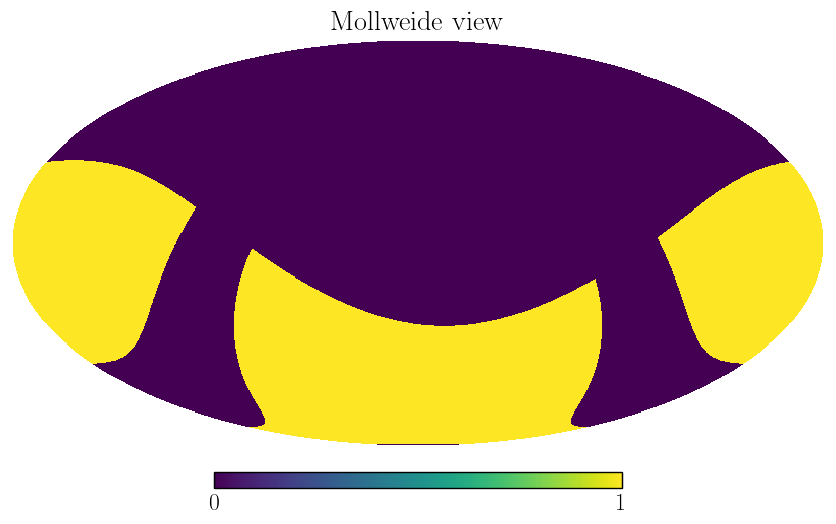

In [55]:
hp.mollview(erosita_western_mask_ecliptic(1024))

In [46]:
np.any(np.abs(lines[0] - 359.9) < 1)

True

In [73]:
lines = mask2contour(erosita_western_mask_ecliptic(1024), Nbins = 100)
# lines = [l for l in lines if not np.any(np.abs(l - 359.9) < 1) ]
# lines = [l for l in lines if not np.any(np.abs(l - 0) < 1) ]

In [74]:
len(lines)

3

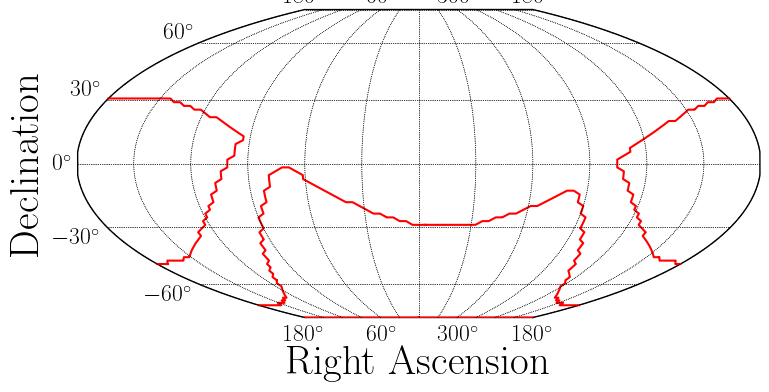

In [75]:
fig, ax = plt.subplots(figsize=(12, 4))
sp = skyproj.McBrydeSkyproj(ax = ax)
for l in lines: sp.draw_polygon(*l.T)

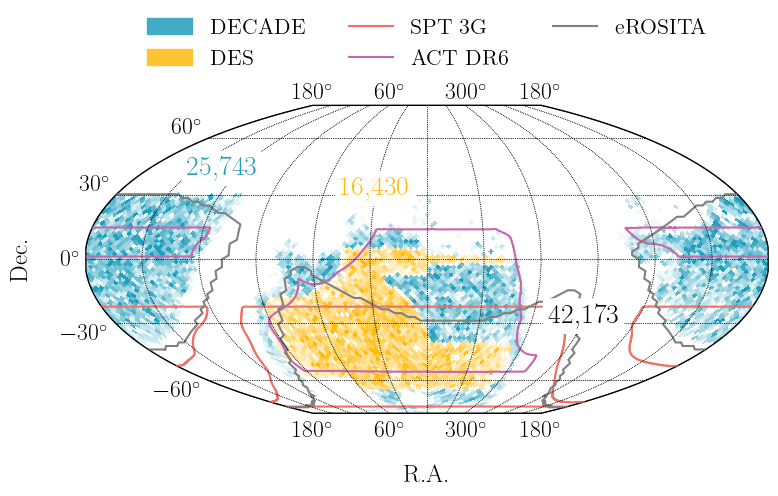

In [78]:
fig, ax = plt.subplots(figsize=(12, 4))
sp = skyproj.McBrydeSkyproj(ax = ax)
# sp.ax.yaxis.tick_right()               # put ticks on the right
# sp.ax.yaxis.set_label_position("right")# move the "Declination" label to the right
# sp.ax.tick_params(axis='y', labelleft=False, labelright=True)

bbox_props = dict(boxstyle="round,pad=0.2",facecolor="white",edgecolor="none",alpha=1, zorder = 100)

NSIDE = 32
Ntot  = 0
data = fitsio.read('/project/kadrlica/dhayaa/Redmapper/DECADE_20260210/Files/my_decade_run_redmapper_v0.8.7_lgt20_vl02_catalog.fit')
maps = np.bincount(hp.ang2pix(NSIDE, data['ra'], data['dec'], lonlat = True), minlength = hp.nside2npix(NSIDE))
maps = np.where(maps > 0, maps, hp.UNSEEN)
sp.draw_hpxmap(maps, cmap = C1, alpha = 1.0, zoom = False)
plt.text(150, 40, f'{len(data):,}', color = 'C1', size = 20, bbox = bbox_props, zorder = 1000)
Ntot += len(data)

data = fitsio.read('/project/kadrlica/dhayaa/Redmapper/DES_20260210/Files/my_decade_run_redmapper_v0.8.7_lgt20_vl02_catalog.fit')
maps = np.bincount(hp.ang2pix(NSIDE, data['ra'], data['dec'], lonlat = True), minlength = hp.nside2npix(NSIDE))
maps = np.where(maps > 0, maps, hp.UNSEEN)
sp.draw_hpxmap(maps, cmap = C2, alpha = 1.0, zoom = False)
sp.ax.text(50, 30, f'{len(data):,}', color = 'C2', size = 20, bbox = bbox_props, zorder = 1000)
Ntot += len(data)

# Create custom legend handles using Patch objects
import matplotlib.patches as mpatches
import matplotlib as mpl

L = []
L.append(mpatches.Patch(color = C1(0.85), label='DECADE'))
L.append(mpatches.Patch(color = C2(0.85), label='DES'))
# L.append(mpatches.Patch(color = C0(0.85), label='DECADE SGC'))

sp.ax.text(290, -30, f'{Ntot:,}', color = 'k', fontsize = 20, bbox = bbox_props, zorder = 1000)

SPT = hp.read_map('/project/chihway/dhayaa/SPT_maps/spt_proposal_2023_13k_sqdeg_field_planckGAL080.fits')
SPT = np.where(SPT > 0.99, 1, hp.UNSEEN)

ACT = hp.read_map('/project2/chihway/dhayaa/ACT_DR6/maps/baseline/mask_act_dr6_lensing_v1_healpix_nside_4096_baseline.fits')
ACT = np.where(ACT > 0.99, 1, hp.UNSEEN)

ERO = erosita_western_mask_ecliptic(256)

lines = mask2contour(SPT, Nbins = 1000)
for l in lines: sp.draw_polygon(*l.T, edgecolor = COLORS[0], lw = 1.5, alpha = 1, linestyle = '-')
    
lines = mask2contour(ACT, Nbins = 1000)
lines[2] = lines[2][lines[2][:, 0] < 179]
lines[3] = lines[3][lines[3][:, 0] > 180]
lines = [np.concatenate([lines[0], lines[1]]), np.concatenate([lines[2], lines[3]])]
lines[1] = reorder_clockwise(lines[1])
for l in lines: sp.draw_polygon(*l.T, edgecolor = COLORS[3], lw = 1.5, alpha = 1, linestyle = '-')

lines = mask2contour(erosita_western_mask_ecliptic(1024), Nbins = 100)
for l in lines: sp.draw_polygon(*l.T, edgecolor = 'gray', lw = 1.5, alpha = 1, linestyle = '-')


L.append(mpl.lines.Line2D([], [], color = COLORS[0], label='SPT 3G'))
L.append(mpl.lines.Line2D([], [], color = COLORS[3], label='ACT DR6'))
L.append(mpl.lines.Line2D([], [], color = 'gray', label='eROSITA'))

# Adding the legend to the plot
sp.ax.legend(handles=L, frameon=False, 
             loc = 'center', bbox_to_anchor=(0.5, 1.2), fontsize = 16, ncol = 3)

sp.ax.set_xlabel('R.A.', fontsize = 18, labelpad = 20)
sp.ax.set_ylabel('Dec.', fontsize = 18, labelpad = 20)

plt.show()